#  AI Crop Health Monitoring System

## Project Overview

Agricultural productivity is highly dependent on the health and condition of crops throughout the growing season. Traditional field-based crop monitoring is often time-consuming, labor-intensive, and difficult to scale across large agricultural regions. Advances in satellite remote sensing and GeoAI provide an efficient alternative for monitoring vegetation health over large areas with high temporal frequency.

This project presents an **AI-powered Crop Health Monitoring System** developed using **Sentinel-2 satellite imagery**, **Google Earth Engine (GEE)**, **ESA WorldCover**, and **Google Gemini AI** to assess crop health in **Kuttanad, Alappuzha, Kerala, India**.

The workflow integrates cloud-filtered Sentinel-2 imagery with cropland masking to isolate agricultural land before calculating multiple vegetation indices, including:

- **NDVI (Normalized Difference Vegetation Index)** – evaluates vegetation vigor.
- **NDRE (Normalized Difference Red Edge Index)** – detects crop stress and chlorophyll variation.
- **EVI (Enhanced Vegetation Index)** – improves vegetation monitoring in dense crop canopies.

Based on these indices, agricultural areas are classified into **Healthy**, **Moderate**, and **Stressed** crop health categories. The system then calculates the spatial extent of each category, generates statistical summaries, produces interactive maps and dashboards, and automatically creates a professional crop health assessment report using **Google Gemini AI**.

This end-to-end GeoAI workflow demonstrates how satellite imagery and artificial intelligence can support **precision agriculture**, **sustainable farming**, and **data-driven agricultural decision-making**.

---

## Study Area

**Location:** Kuttanad, Alappuzha, Kerala, India

**Satellite Data:** Sentinel-2 Surface Reflectance (COPERNICUS/S2_SR_HARMONIZED)

**Land Cover Data:** ESA WorldCover

**Platform:** Google Earth Engine

**Programming Language:** Python

**Analysis Year:** 2024

---

## Project Objectives

- Monitor crop health using Sentinel-2 satellite imagery.
- Remove cloud contamination using cloud filtering techniques.
- Extract cropland using ESA WorldCover.
- Calculate NDVI, NDRE, and EVI vegetation indices.
- Classify agricultural fields into Healthy, Moderate, and Stressed categories.
- Calculate crop health area statistics.
- Visualize results through interactive GIS maps and dashboards.
- Generate an AI-powered crop health assessment report using Google Gemini AI.

---

## Expected Outputs

- Crop Health Classification Map
- Crop Health Statistics (km²)
- Bar Chart & Pie Chart
- Results Dashboard
- AI-generated Crop Health Assessment Report

### Install Libraries

In [ ]:
# Install Required Libraries
!pip install -q earthengine-api geemap google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 46.4 MB/s eta 0:00:00


### Import Libraries

In [ ]:
# Import Libraries
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Initialize Google Earth Engine

In [ ]:
# Authenticate & Initialize Google Earth Engine
ee.Authenticate()
ee.Initialize(project='active-venture-461910-q0')

### Initialize Gemini AI

In [ ]:
from google.colab import userdata
from google import genai

API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=API_KEY)

print("Gemini AI Connected")

Gemini AI Connected


### Study Area

In [ ]:
# Load Kerala district boundaries
districts = ee.FeatureCollection("FAO/GAUL/2015/level2")

# Select Alappuzha district
alappuzha = districts.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM1_NAME", "Kerala"),
        ee.Filter.eq("ADM2_NAME", "Alappuzha")
    )
)

Map = geemap.Map()

Map.centerObject(alappuzha, 11)

Map.addLayer(
    alappuzha,
    {'color': 'red'},
    'Alappuzha District'
)

Map

Map(center=[9.41796636413538, 76.44346118879182], controls=(WidgetControl(options=['position', 'transparent_bg…

### Workflow Diagram


---


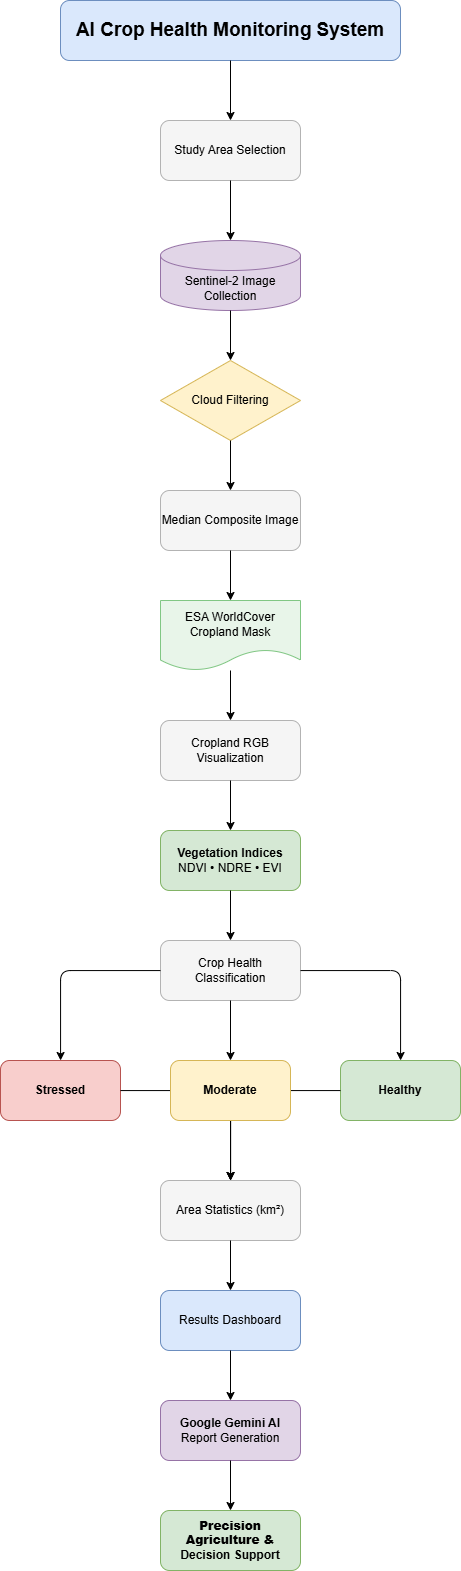

The following workflow summarizes the end-to-end GeoAI pipeline implemented in this project, from Sentinel-2 image acquisition to AI-generated crop health reporting

### Sentinel-2 Data Collection

In [ ]:
# Load Sentinel-2 Image Collection
sentinel = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(alappuzha)

### Cloud Filtering

In [ ]:
# Function to remove clouds and cirrus using the QA60 band
def maskS2clouds(image):

    qa = image.select('QA60')

    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloudBitMask).eq(0)
        .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    )

    return (
        image.updateMask(mask)
             .divide(10000)
             .copyProperties(image, ["system:time_start"])
    )

### Apply Cloud Mask & Filter Images

In [ ]:
# Filter by date, cloud percentage and apply cloud masking
sentinel = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(alappuzha)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
)

image = sentinel.median().clip(alappuzha)

### Median Composite

In [ ]:
# Create Median Composite
image = sentinel.median().clip(alappuzha)

### True Color Composite

In [ ]:
# True Color Composite
Map = geemap.Map()

Map.centerObject(alappuzha, 11)

Map.addLayer(
    image,
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000
    },
    "Original Image"
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

### ESA WorldCover Cropland Mask

In [ ]:
# Crop Mask using ESA WorldCover
# Load ESA WorldCover
# Load ESA WorldCover 2021
worldcover = ee.Image("ESA/WorldCover/v200/2021")

In [ ]:
# Create Cropland Mask
cropland = worldcover.eq(40)

In [ ]:
# Display Cropland
Map = geemap.Map()

Map.centerObject(alappuzha,11)

Map.addLayer(
    cropland.selfMask(),
    {
        'palette':['green']
    },
    "Cropland"
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

In [ ]:
# Apply Cropland Mask
crop_image = image.updateMask(cropland)

### Cropland RGB Visualization

In [ ]:
# Display Cropland RGB
Map = geemap.Map()

Map.centerObject(alappuzha, 11)

Map.addLayer(
    crop_image,
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000
    },
    "Cropland RGB"
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

### NDVI Calculation

In [ ]:
# Calculate Normalized Difference Vegetation Index (NDVI)
# Formula: (NIR - Red) / (NIR + Red)
ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')

In [ ]:
Map = geemap.Map()

Map.centerObject(alappuzha,11)

Map.addLayer(
    ndvi,
    {
        'min':-1,
        'max':1,
        'palette':['red','yellow','green']
    },
    'NDVI'
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

### NDRE Calculation

In [ ]:
# Calculate Normalized Difference Red Edge (NDRE)
# Formula: (NIR - RedEdge) / (NIR + RedEdge)
ndre = image.normalizedDifference(['B8','B5']).rename('NDRE')

In [ ]:
Map = geemap.Map()

Map.centerObject(alappuzha,11)

Map.addLayer(
    ndre,
    {
        'min':-1,
        'max':1,
        'palette':['red','yellow','green']
    },
    'NDRE'
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

# EVI Calculation

## Enhanced Vegetation Index (EVI)

The **Enhanced Vegetation Index (EVI)** is an advanced vegetation index designed to improve vegetation monitoring by reducing atmospheric effects and minimizing background soil influences. Compared to NDVI, EVI is more effective in areas with dense vegetation and provides improved sensitivity to variations in canopy structure.

### Formula

```text
EVI = 2.5 × (NIR − Red) / (NIR + 6 × Red − 7.5 × Blue + 1)
```

Where:

- **NIR** = Near Infrared Band (Band 8)
- **Red** = Red Band (Band 4)
- **Blue** = Blue Band (Band 2)

### Purpose

In this project, EVI is used to:

- Assess vegetation vigor and density.
- Improve crop health monitoring in dense agricultural areas.
- Reduce atmospheric and soil background effects.
- Complement NDVI and NDRE for a more reliable crop health assessment.

### Output

The resulting EVI map highlights variations in crop health across the study area, providing valuable insights for precision agriculture, vegetation monitoring, and sustainable farming practices.

In [ ]:
# Enhanced Vegetation Index (EVI)
# Formula:
evi = image.expression(

'2.5*((NIR-RED)/(NIR+6*RED-7.5*BLUE+1))',

{
'NIR':image.select('B8'),
'RED':image.select('B4'),
'BLUE':image.select('B2')
}

).rename('EVI')

In [ ]:
Map = geemap.Map()

Map.centerObject(alappuzha,11)

Map.addLayer(
    evi,
    {
        'min':-1,
        'max':1,
        'palette':['red','yellow','green']
    },
    'EVI'
)

Map

Map(center=[9.41796636413538, 76.44346118879182], controls=(WidgetControl(options=['position', 'transparent_bg…

### Crop Health Classification

In [ ]:
# Crop Health Classification
healthy = ndvi.gt(0.7)

moderate = ndvi.gte(0.5).And(ndvi.lte(0.7))

stressed = ndvi.lt(0.5)

### Crop Health Map

In [ ]:
# Crop Health Map
Map = geemap.Map()

Map.centerObject(alappuzha,11)

Map.addLayer(stressed.selfMask(),
             {'palette':'red'},
             "Stressed")

Map.addLayer(moderate.selfMask(),
             {'palette':'yellow'},
             "Moderate")

Map.addLayer(healthy.selfMask(),
             {'palette':'green'},
             "Healthy")

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

## Crop Health Statistics

### Crop Health Area Statistics

In [ ]:
# Area Calculation
def calculate_area(image):

    area = (
        image.selfMask()
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=alappuzha.geometry(),
            scale=10,
            maxPixels=1e13
        )
    )

    return list(area.getInfo().values())[0]/1e6

### Results Dashboard

In [ ]:
# Calculate crop health areas
healthy_area = calculate_area(healthy)

moderate_area = calculate_area(moderate)

stressed_area = calculate_area(stressed)

In [ ]:
# Display Statistics
print("Crop Health Statistics")
print("-" * 35)

print(f"Healthy Crop Area   : {healthy_area:.2f} km²")
print(f"Moderate Crop Area  : {moderate_area:.2f} km²")
print(f"Stressed Crop Area  : {stressed_area:.2f} km²")

total_crop = healthy_area + moderate_area + stressed_area

print("-" * 35)
print(f"Total Cropland      : {total_crop:.2f} km²")

Crop Health Statistics
-----------------------------------
Healthy Crop Area   : 582.32 km²
Moderate Crop Area  : 433.29 km²
Stressed Crop Area  : 295.66 km²
-----------------------------------
Total Cropland      : 1311.27 km²


In [ ]:
# Crop Health Statistics Table
import pandas as pd

crop_results = pd.DataFrame({

    "Crop Health": [
        "Healthy",
        "Moderate",
        "Stressed"
    ],

    "Area (km²)": [
        round(healthy_area,2),
        round(moderate_area,2),
        round(stressed_area,2)
    ]

})

crop_results

,Crop Health,Area (km²)
0,Healthy,582.32
1,Moderate,433.29
2,Stressed,295.66


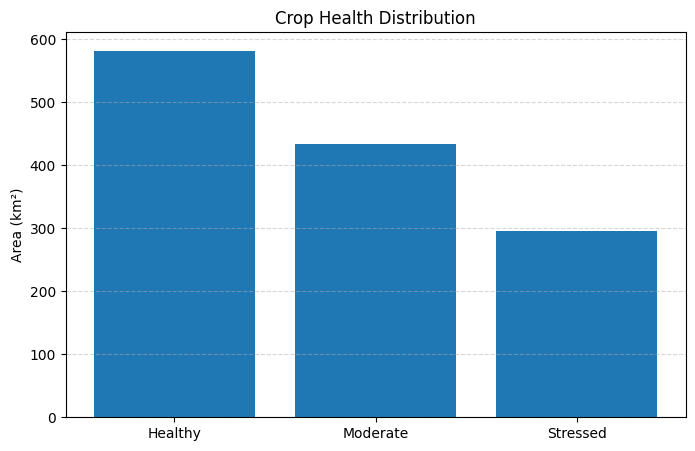

In [ ]:
# Bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    crop_results["Crop Health"],
    crop_results["Area (km²)"]
)

plt.title("Crop Health Distribution")
plt.ylabel("Area (km²)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

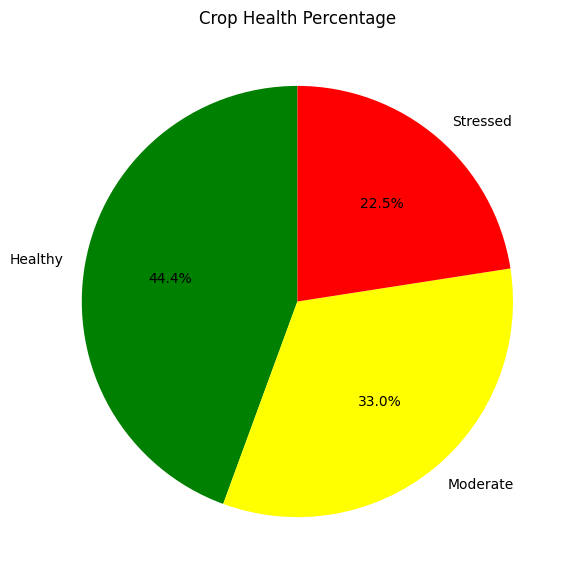

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

# Define colors for each category
colors = ['green', 'yellow', 'red']

plt.pie(
    crop_results["Area (km²)"],
    labels=crop_results["Crop Health"],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors # Apply the custom colors
)

plt.title("Crop Health Percentage")

plt.show()

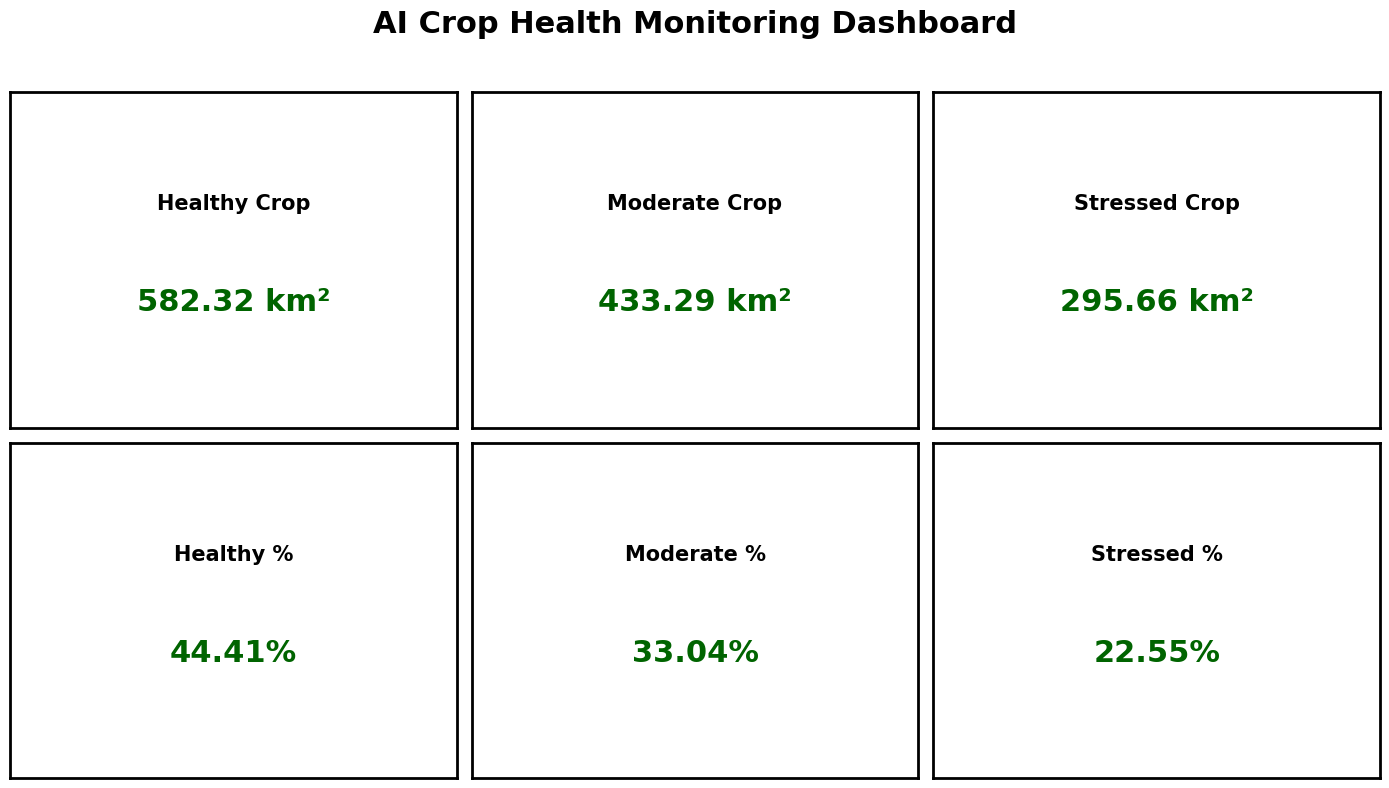

In [ ]:
# KPI Dashboard
import matplotlib.pyplot as plt

healthy = round(healthy_area,2)
moderate = round(moderate_area,2)
stressed = round(stressed_area,2)

total = healthy + moderate + stressed

healthy_pct = round((healthy/total)*100,2)
moderate_pct = round((moderate/total)*100,2)
stressed_pct = round((stressed/total)*100,2)

fig = plt.figure(figsize=(14,8))
fig.patch.set_facecolor("white")

plt.suptitle(
    "AI Crop Health Monitoring Dashboard",
    fontsize=22,
    fontweight="bold"
)

cards = [

("Healthy Crop",f"{healthy} km²"),

("Moderate Crop",f"{moderate} km²"),

("Stressed Crop",f"{stressed} km²"),

("Healthy %",f"{healthy_pct}%"),

("Moderate %",f"{moderate_pct}%"),

("Stressed %",f"{stressed_pct}%")

]

for i,(title,value) in enumerate(cards):

    ax = fig.add_subplot(2,3,i+1)

    ax.text(
        0.5,
        0.65,
        title,
        fontsize=15,
        ha="center",
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.35,
        value,
        fontsize=22,
        ha="center",
        color="darkgreen",
        fontweight="bold"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for s in ax.spines.values():
        s.set_visible(True)
        s.set_linewidth(2)

plt.tight_layout(rect=[0,0,1,0.95])

plt.savefig(
    "results_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## AI Report Generation

### Prompt Engineering

Google Gemini AI is used to automatically generate a professional crop health assessment report based on the calculated statistics.

In [ ]:
# Generate AI Crop Health Assessment Report


report = client.models.generate_content(

    model="gemini-2.5-flash",

    contents=f"""

Generate a professional Crop Health Assessment Report.

Study Area:
Kuttanad, Alappuzha, Kerala, India

Year:
2024

Crop Health Statistics

Healthy Crop Area:
{healthy_area:.2f} km²

Moderate Crop Area:
{moderate_area:.2f} km²

Stressed Crop Area:
{stressed_area:.2f} km²

The report should contain the following sections:

1. Executive Summary

2. Crop Health Analysis

3. Interpretation of Healthy, Moderate and Stressed Areas

4. Agricultural Implications

5. Recommendations for Farmers

6. Recommendations for Government Agencies

7. Conclusion

Write the report in a professional style suitable for an agricultural department.

"""
)

print(report.text)

## Crop Health Assessment Report - Kuttanad, Alappuzha, Kerala (2024)

**Prepared For:**
The Department of Agriculture, Government of Kerala

**Date:**
October 26, 2024

**Study Area:**
Kuttanad Region, Alappuzha District, Kerala, India

**Assessment Year:**
2024

---

### 1. Executive Summary

This report presents a comprehensive assessment of crop health in the Kuttanad region of Alappuzha, Kerala, for the year 2024. The assessment covers a total cultivated area of 1311.27 km², categorizing crop health into three distinct levels: Healthy, Moderate, and Stressed. The findings indicate that while a significant portion (44.41%) of the cultivated land remains healthy, a substantial majority (55.59%) is currently experiencing some level of stress, with 33.04% showing moderate stress and a critical 22.55% exhibiting severe stress. This distribution highlights a pressing need for targeted interventions to mitigate yield losses, ensure food security, and support the livelihoods of farmers in

In [ ]:
# Save Report
with open(
    "Crop_Health_Assessment_Report.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(report.text)

print("Report Saved Successfully")

Report Saved Successfully


In [ ]:
from google.colab import files

files.download("Crop_Health_Assessment_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Export Results

In [ ]:
# Export Crop Health Statistics

import pandas as pd

results = pd.DataFrame({

    "Category":[
        "Healthy",
        "Moderate",
        "Stressed"
    ],

    "Area (km²)":[
        round(healthy_area,2),
        round(moderate_area,2),
        round(stressed_area,2)
    ]

})

results.to_csv(
    "Crop_Health_Statistics.csv",
    index=False
)

print(results)

print("Statistics Exported")

   Category  Area (km²)
0   Healthy      582.32
1  Moderate      433.29
2  Stressed      295.66
Statistics Exported


## Conclusion

This project demonstrates an end-to-end GeoAI workflow for crop health monitoring using Sentinel-2 satellite imagery, Google Earth Engine, ESA WorldCover, vegetation indices, and Google Gemini AI.

The workflow successfully:

- Monitored crop health using NDVI, NDRE, and EVI.
- Classified agricultural land into Healthy, Moderate, and Stressed categories.
- Calculated crop health statistics.
- Produced interactive GIS maps and visual dashboards.
- Generated an AI-powered crop health assessment report.

This workflow demonstrates how GeoAI can support precision agriculture by integrating satellite remote sensing, cloud-based geospatial analysis, and generative AI for scalable crop health monitoring.